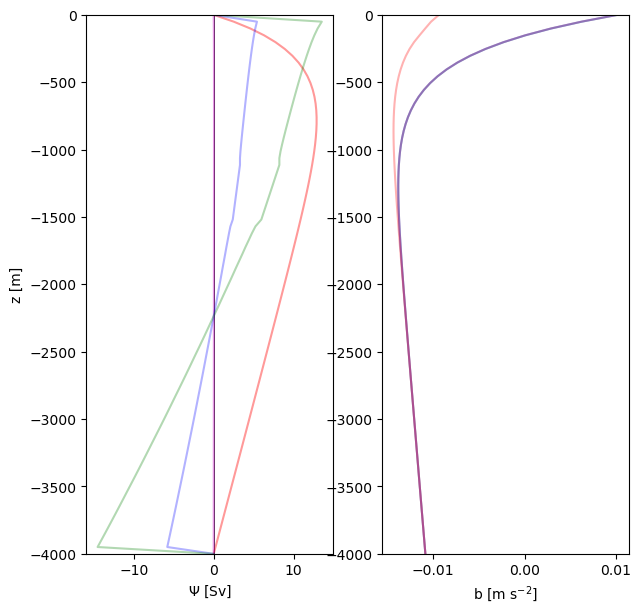

t ≈ 0 years
t ≈ 500 years
t ≈ 1000 years
t ≈ 1500 years
t ≈ 2000 years
t ≈ 2500 years
t ≈ 3000 years
t ≈ 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_1900/553216340.py:647: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


<Figure size 640x480 with 0 Axes>

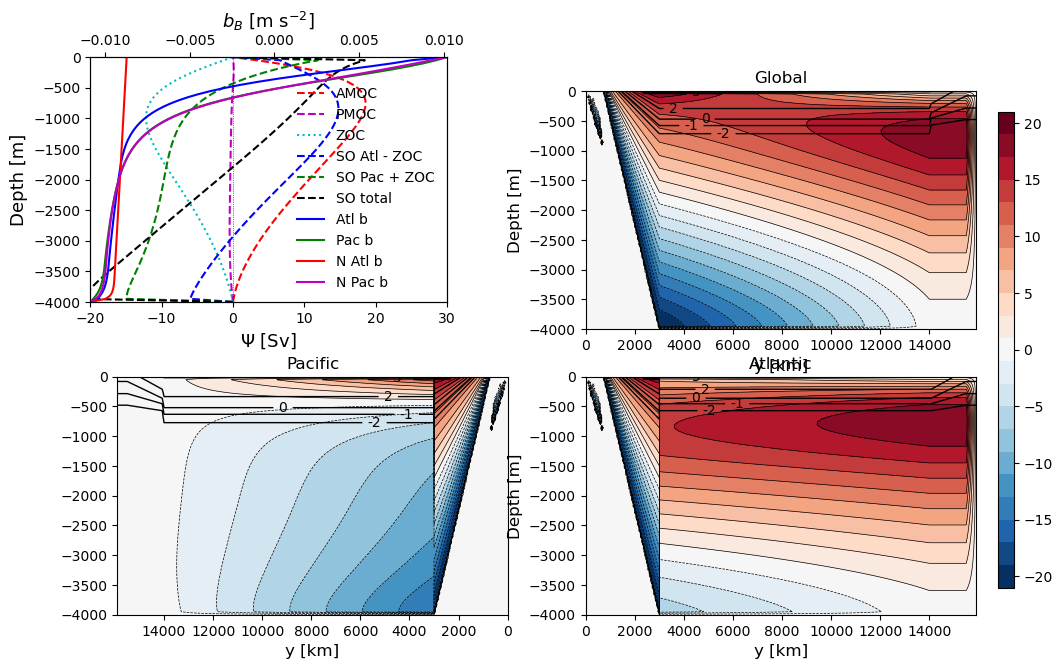

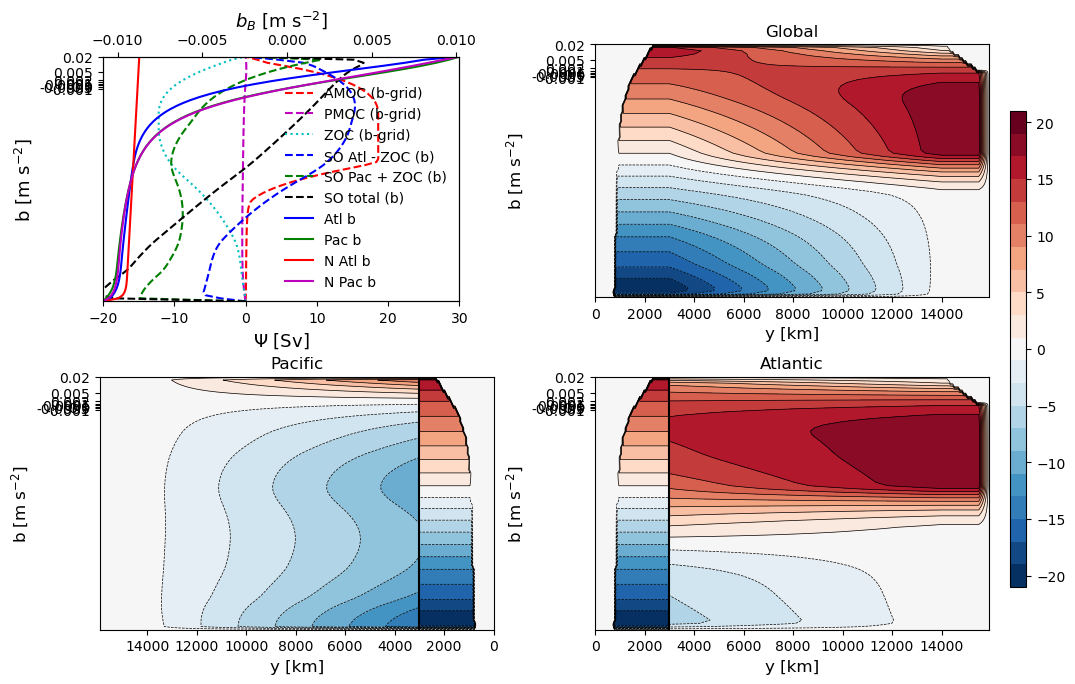

In [1]:
"""
Four-column THERMOHALINE MOC (buoyancy decomposed into temp and salinity) 

FOur Columns are :
  * Atlantic basin (Atl)
  * Pacific basin (Pac)
  * North Atlantic sinking region (north_Atl)
  * North Pacific sinking region (north_Pac)

Southern Ocean channel connects both basins, but surface temperature is a random-ish function 
to vary between 2 -5 degrees. Needs more work to match southern ocean buoyancy in J&N model

Notes on dynamics:
  * Prognostic T(z,t), S(z,t) in each column (ThermohalineColumn)
  * Buoyancy: b = g[α(T - T0) - β(S - S0)] (diagnosed)
  * Overturning: TH_Psi_Thermwind, TH_Psi_SO using b(T,S)
"""

import numpy as np
from matplotlib import pyplot as plt

from pymoc.modules import ThermohalineColumn, TH_Psi_Thermwind, TH_Psi_SO
from pymoc.plotting import Interpolate_channel, Interpolate_twocol


g     = 9.81      # m/s^2

#(all taken from Johnson et al., 2007 peper)
alpha = 2e-4      # 1/degC 
beta  = 8e-4      # 1/psu 
T0    = 5.0       # degC 
S0    = 35.0      # psu 


f    = 1e-4       # Coriolis
rho  = 1030.0     # kg/m^3
KGM  = 1800.0     # GM coefficient


z = np.linspace(-4000, 0, 80)

y = np.linspace(0, 3.0e6, 51)

A_Atl        = 7e13
A_north_atl  = 5.5e12
A_Pac        = 1.7e14 - 5.5e12     
A_north_pac  = 5.5e12              

Lx   = 1.3e7         
Latl = 6.0 / 21. * Lx
Lpac = 15.0 / 21. * Lx


dt           = 86400.0 * 30.  
MOC_up_iters = int(np.floor(2. * 360 * 86400 / dt))
plot_iters   = int(np.ceil(500 * 360 * 86400 / dt))
total_iters  = int(np.ceil(4000 * 360 * 86400 / dt))


def kappaeff(z):
    """
    Effective vertical diffusivity with a bottom boundary layer taper.
    Same shape as original kappaeff but now applied to T and S.
    """
    return (1.0 * (1e-4 * (1.1 - np.tanh(
                np.maximum(z + 2000., 0) / 1000.
                + np.minimum(z + 2000., 0) / 1300.
            )))
            * (1. - np.maximum(-4000. - z + 600., 0.) / 600.)**2)


T_deep = 2.5      
S_deep = 35.76  

Ts_Atl       = 25.0   # from Johnson paper T_t for both basins
Ss_Atl       = 38.7   # salinity for buoyancy equiv to J&N paper
Ts_Pac       = 25.0   
Ss_Pac       = 38.7   

Ts_north_atl = 0.1795   # from Jansen and Nadeau reference GCM run 
Ss_north_atl = 35   
Ts_north_pac = 0.1795    
Ss_north_pac = 32.5   

Tbot = T_deep
Sbot = S_deep

# def T_profile(z, Ts, Tdeep, hT=300.):
#     return Tdeep + (Ts - Tdeep) * np.exp(z / hT)

def T_profile(z, Ts, Tdeep):
    return Ts*np.exp(z/300.)+z/z[0]*Tbot

def S_profile(z, Ss, Sdeep, hS=300.):
    return Sdeep + (Ss - Sdeep) * np.exp(z / hS)

# def S_profile(z, Ss, Sdeep):
#     return Ss*np.exp(z/300)+z/z[0]*Sbot


T_Atl0        = T_profile(z, Ts_Atl,       T_deep)
S_Atl0        = S_profile(z, Ss_Atl,       S_deep)
T_Pac0        = T_profile(z, Ts_Pac,       T_deep)
S_Pac0        = S_profile(z, Ss_Pac,       S_deep)
T_north_atl0  = T_profile(z, Ts_north_atl, T_deep)
S_north_atl0  = S_profile(z, Ss_north_atl, S_deep)
T_north_pac0  = T_profile(z, Ts_north_pac, T_deep)
S_north_pac0  = S_profile(z, Ss_north_pac, S_deep)



Ts_SO = 5.0 - 7.0 * np.cos(np.pi * (y - 1.0e5) / (3.0e6))   # ~ 5 to -2 °C
# Ts_SO = 38.7 * np.ones_like(y)                              
Ss_SO = 35 * np.ones_like(y)                              

bs_SO = g * (alpha * (Ts_SO - T0) - beta * (Ss_SO - S0))  



tau = 0.16  # N/m^2 wind stress


N2min = 2e-7

Atl = ThermohalineColumn(
    z=z,
    kappa=kappaeff,
    Area=A_Atl,
    T=T_Atl0,
    S=S_Atl0,
    Ts=Ts_Atl,
    Tbot=Tbot,
    Ss=Ss_Atl,
    Sbot=Sbot,
    g=g, alpha=alpha, beta=beta, T0=T0, S0=S0,
    N2min=N2min
)

north_Atl = ThermohalineColumn(
    z=z,
    kappa=kappaeff,
    Area=A_north_atl,
    T=T_north_atl0,
    S=S_north_atl0,
    Ts=Ts_north_atl,
    Tbot=Tbot,
    Ss=Ss_north_atl,
    Sbot=Sbot,
    g=g, alpha=alpha, beta=beta, T0=T0, S0=S0,
    N2min=N2min
)

Pac = ThermohalineColumn(
    z=z,
    kappa=kappaeff,
    Area=A_Pac,
    T=T_Pac0,
    S=S_Pac0,
    Ts=Ts_Pac,
    Tbot=Tbot,
    Ss=Ss_Pac,
    Sbot=Sbot,
    g=g, alpha=alpha, beta=beta, T0=T0, S0=S0,
    N2min=N2min
)

north_Pac = ThermohalineColumn(
    z=z,
    kappa=kappaeff,
    Area=A_north_pac,
    T=T_north_pac0,
    S=S_north_pac0,
    Ts=Ts_north_pac,
    Tbot=Tbot,
    Ss=Ss_north_pac,
    Sbot=Sbot,
    g=g, alpha=alpha, beta=beta, T0=T0, S0=S0,
    N2min=N2min
)


AMOC = TH_Psi_Thermwind(z=z, col1=Atl, col2=north_Atl, f=f)
AMOC.solve()
Psi_iso_Atl, Psi_iso_NAtl = AMOC.Psibz()

PMOC = TH_Psi_Thermwind(z=z, col1=Pac, col2=north_Pac, f=f)
PMOC.solve()
Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

ZOC = TH_Psi_Thermwind(z=z, col1=Atl, col2=Pac, f=f)
ZOC.solve()
Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

SO_Atl = TH_Psi_SO(
    z=z, y=y,
    col_basin=Atl,
    bs=bs_SO,
    tau=tau,
    f=f, rho=rho,
    L=Latl, KGM=KGM
)
SO_Atl.solve()

SO_Pac = TH_Psi_SO(
    z=z, y=y,
    col_basin=Pac,
    bs=bs_SO,
    tau=tau,
    f=f, rho=rho,
    L=Lpac, KGM=KGM
)
SO_Pac.solve()


fig_evo = plt.figure(figsize=(7, 7))
ax_psi = fig_evo.add_subplot(121)
ax_b   = fig_evo.add_subplot(122)
for ax in (ax_psi, ax_b):
    ax.set_ylim([-4000, 0])
ax_psi.set_xlabel(r'$\Psi$ [Sv]')
ax_psi.set_ylabel('z [m]')
ax_b.set_xlabel('b [m s$^{-2}$]')
ax_psi.axvline(0, color='k', linewidth=0.5)


for ii in range(total_iters):
    wA_Atl  = (Psi_iso_Atl    + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
    wA_NAtl = -Psi_iso_NAtl   * 1e6
    wA_Pac  = (-Psi_zonal_Pac - SO_Pac.Psi    + Psi_iso_Pac) * 1e6
    wA_NPac = -Psi_iso_NPac   * 1e6

    vA_Atl = np.gradient(((Psi_iso_Atl    + Psi_zonal_Atl - SO_Atl.Psi) * 1e6), z)
    vA_NAtl = -np.gradient((Psi_iso_NAtl   * 1e6), z)
    vA_Pac  = np.gradient(((-Psi_zonal_Pac - SO_Pac.Psi    + Psi_iso_Pac) * 1e6), z)
    vA_NPac = -np.gradient((Psi_iso_NPac   * 1e6),z)

    Atl.timestep(      wA=wA_Atl,  dt=dt, do_conv=False, vdx_in = vA_Atl, S_in = north_Atl.S, T_in = north_Atl.T)
    north_Atl.timestep(wA=wA_NAtl, dt=dt, do_conv=True, vdx_in = vA_NAtl, S_in = Atl.S, T_in = Atl.T)
    Pac.timestep(      wA=wA_Pac,  dt=dt, do_conv=False, vdx_in = vA_Pac, S_in = north_Pac.S, T_in = north_Pac.T)
    north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True, vdx_in = vA_NPac, S_in = Pac.S, T_in = Pac.T)

    if ii % MOC_up_iters == 0:
        AMOC.update(col1=Atl, col2=north_Atl)
        AMOC.solve()
        Psi_iso_Atl, Psi_iso_NAtl = AMOC.Psibz()

        PMOC.update(col1=Pac, col2=north_Pac)
        PMOC.solve()
        Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

        ZOC.update(col1=Atl, col2=Pac)
        ZOC.solve()
        Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

        SO_Atl.update(col_basin=Atl)
        SO_Atl.solve()
        SO_Pac.update(col_basin=Pac)
        SO_Pac.solve()

    if ii % plot_iters == 0:
        ax_psi.plot(AMOC.Psi, z, 'r-',  alpha=0.4)
        ax_psi.plot(PMOC.Psi, z, 'm-',  alpha=0.4)
        ax_psi.plot(SO_Atl.Psi, z, 'b-', alpha=0.3)
        ax_psi.plot(SO_Pac.Psi, z, 'g-', alpha=0.3)

        ax_b.plot(Atl.b,       z, 'b-', alpha=0.3)
        ax_b.plot(Pac.b,       z, 'g-', alpha=0.3)
        ax_b.plot(north_Atl.b, z, 'r-', alpha=0.3)
        ax_b.plot(north_Pac.b, z, 'm-', alpha=0.3)
        plt.pause(0.01)
        print("t ≈", round(ii * dt / (360 * 86400.)), "years")

ax_psi.plot(AMOC.Psi, z, 'r-', linewidth=2, label='AMOC')
ax_psi.plot(PMOC.Psi, z, 'm-', linewidth=2, label='PMOC')
ax_psi.plot(SO_Atl.Psi, z, 'b--', linewidth=1.5, label='SO Atl')
ax_psi.plot(SO_Pac.Psi, z, 'g--', linewidth=1.5, label='SO Pac')
ax_psi.legend(loc='lower right')

ax_b.plot(Atl.b,       z, 'b-', linewidth=2, label='Atl')
ax_b.plot(Pac.b,       z, 'g-', linewidth=2, label='Pac')
ax_b.plot(north_Atl.b, z, 'r-', linewidth=2, label='N Atl')
ax_b.plot(north_Pac.b, z, 'm-', linewidth=2, label='N Pac')
ax_b.legend(loc='lower right')
plt.tight_layout()


blevs = np.array([-0.004, -0.002, 0.0, 0.004, 0.01, 0.018])
plevs = np.arange(-21., 23., 2.0)
nb    = 500

b_basin = (A_Atl * Atl.b + A_Pac * Pac.b) / (A_Atl + A_Pac)
b_north_mean = (A_north_atl * north_Atl.b + A_north_pac * north_Pac.b) / (A_north_atl + A_north_pac)

PsiSO = (np.interp(b_basin, Atl.b, SO_Atl.Psi) +
         np.interp(b_basin, Pac.b, SO_Pac.Psi))

AMOC_bbasin = np.interp(b_basin, AMOC.bgrid, AMOC.Psib(nb=nb))
PMOC_bbasin = np.interp(b_basin, PMOC.bgrid, PMOC.Psib(nb=nb))

l = y[-1]

bs_loc = 1.*bs_SO.copy()
bn_loc = 1.*b_basin.copy()
bs_loc[-1] = 1.*bn_loc[-1]

# bn = b_north.copy()
# bn[0] = b_basin[0]

bs=1.*bs_SO
bn=1.*b_basin
bs[0]=1.*bn[0]

bint = Interpolate_channel(y=y, z=z, bs=bs, bn=bn)
bsouth = bint.gridit() 

# # ## chatgpt fix (try rewrite)
# try:
#     bint = Interpolate_channel(y=y, z=z, bs=bs_loc, bn=bn_loc)
#     bsouth = bint.gridit()              # shape (len(y), len(z))
# except ValueError:
#     # Fallback: fill the channel with the basin-mean buoyancy profile
#     # everywhere in y. This preserves the rest of the fancy plotting.
#     print("Interpolate_channel failed; using simple y-uniform channel buoyancy for plotting.")
#     bsouth = np.tile(b_basin, (len(y), 1))   # (Ny, Nz)


lbasin   = 11000.
ltrans   = 1500.
lnorth   = 400.
lchannel = l / 1e3

ybasin = np.linspace(0, lbasin, 60) + lchannel
bbasin = np.tile(b_basin, (len(ybasin), 1))
bAtl   = np.tile(Atl.b,   (len(ybasin), 1))
bPac   = np.tile(Pac.b,   (len(ybasin), 1))

ytrans = np.linspace(ltrans / 20., ltrans, 20) + lchannel + lbasin
bn_tmp = b_north_mean.copy()
bn_tmp[0] = b_basin[0]   # match bottom b
bint = Interpolate_twocol(
    y=ytrans * 1000. - ytrans[0] * 1000., z=z,
    bs=Atl.b, bn=bn_tmp
)
btrans = bint.gridit()

ynorth     = np.linspace(lnorth / 20., lnorth, 20) + lchannel + lbasin + ltrans
bnorth     = np.tile(bn_tmp, (len(ynorth), 1))
bnorth_atl = np.tile(bn_tmp, (len(ynorth), 1))
bnorth_pac = np.tile(bn_tmp, (len(ynorth), 1))

ynew     = np.concatenate((y / 1e3, ybasin, ytrans, ynorth))
bnew     = np.concatenate((bsouth, bbasin, btrans, bnorth))
bnew_Atl = np.concatenate((bsouth, bAtl,   btrans, bnorth_atl))
bnew_Pac = np.concatenate((bsouth, bPac,   btrans, bnorth_pac))

psiarray_b      = np.zeros((len(ynew), len(z)))
psiarray_b_Atl  = np.zeros((len(ynew), len(z)))
psiarray_b_Pac  = np.zeros((len(ynew), len(z)))
psiarray_Atl    = np.zeros((len(ynew), len(z)))
psiarray_Pac    = np.zeros((len(ynew), len(z)))
psiarray_z      = np.zeros((len(ynew), len(z)))
psiarray_z_Atl  = np.zeros((len(ynew), len(z)))
psiarray_z_Pac  = np.zeros((len(ynew), len(z)))

for iy in range(1, len(y)):
    psiarray_z[iy, :]      = np.interp(bnew[iy, :], b_basin, SO_Atl.Psi + SO_Pac.Psi)
    psiarray_z_Atl[iy, :]  = psiarray_z[iy, :]
    psiarray_z_Pac[iy, :]  = psiarray_z[iy, :]
    psiarray_b[iy, b_basin < bs_SO[iy]] = PsiSO[b_basin < bs_SO[iy]]
    psiarray_Atl[iy, :]    = np.interp(bnew[iy, :], b_basin, PsiSO)
    psiarray_b_Atl[iy, :]  = psiarray_b[iy, :]
    psiarray_Pac[iy, :]    = np.interp(bnew[iy, :], b_basin, PsiSO)
    psiarray_b_Pac[iy, :]  = psiarray_b[iy, :]

for iy in range(len(y), len(y) + len(ybasin)):
    psiarray_z[iy, :] = (
        (ynew[iy] - lchannel) * (AMOC.Psi + PMOC.Psi) +
        (lchannel + lbasin - ynew[iy]) * (SO_Atl.Psi + SO_Pac.Psi)
    ) / lbasin

    psiarray_z_Atl[iy, :] = (
        (ynew[iy] - lchannel) * AMOC.Psi +
        (lchannel + lbasin - ynew[iy]) * (SO_Atl.Psi - ZOC.Psi)
    ) / lbasin

    psiarray_z_Pac[iy, :] = (
        (ynew[iy] - lchannel) * PMOC.Psi +
        (lchannel + lbasin - ynew[iy]) * (SO_Pac.Psi + ZOC.Psi)
    ) / lbasin

    psiarray_b[iy, :] = (
        (ynew[iy] - lchannel) * (AMOC_bbasin + PMOC_bbasin) +
        (lchannel + lbasin - ynew[iy]) * PsiSO
    ) / lbasin

    psiarray_Atl[iy, :] = (
        (ynew[iy] - lchannel) * AMOC.Psibz(nb=nb)[0] +
        (lchannel + lbasin - ynew[iy]) * (SO_Atl.Psi - ZOC.Psibz()[0])
    ) / lbasin

    psiarray_b_Atl[iy, :] = (
        (ynew[iy] - lchannel) * AMOC_bbasin +
        (lchannel + lbasin - ynew[iy]) * (
            np.interp(b_basin, Atl.b, SO_Atl.Psi) -
            np.interp(b_basin, ZOC.bgrid, ZOC.Psib())
        )
    ) / lbasin

    psiarray_Pac[iy, :] = (
        (ynew[iy] - lchannel) * PMOC.Psibz(nb=nb)[0] +
        (lchannel + lbasin - ynew[iy]) * (SO_Pac.Psi + ZOC.Psibz()[0])
    ) / lbasin

    psiarray_b_Pac[iy, :] = (
        (ynew[iy] - lchannel) * PMOC_bbasin +
        (lchannel + lbasin - ynew[iy]) * (
            np.interp(b_basin, Pac.b, SO_Pac.Psi) +
            np.interp(b_basin, ZOC.bgrid, ZOC.Psib())
        )
    ) / lbasin

for iy in range(len(y) + len(ybasin), len(y) + len(ybasin) + len(ytrans)):
    psiarray_z[iy, :]      = AMOC.Psi + PMOC.Psi
    psiarray_z_Atl[iy, :]  = AMOC.Psi
    psiarray_z_Pac[iy, :]  = PMOC.Psi

    mask = (b_basin < bnew[iy, -1])
    psiarray_b[iy, mask]      = AMOC_bbasin[mask] + PMOC_bbasin[mask]
    psiarray_Atl[iy, mask]    = AMOC_bbasin[mask]
    psiarray_b_Atl[iy, mask]  = psiarray_Atl[iy, mask]
    psiarray_Pac[iy, mask]    = PMOC_bbasin[mask]
    psiarray_b_Pac[iy, mask]  = psiarray_Pac[iy, mask]

for iy in range(len(y) + len(ybasin) + len(ytrans), len(ynew)):
    factor = max(0.0, (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth)

    psiarray_z[iy, :]      = factor * (AMOC.Psi + PMOC.Psi)
    psiarray_z_Atl[iy, :]  = factor * AMOC.Psi
    psiarray_z_Pac[iy, :]  = factor * PMOC.Psi

    mask = (b_basin < bnew[iy, -1])
    psiarray_b[iy, mask]      = factor * (AMOC_bbasin[mask] + PMOC_bbasin[mask])
    psiarray_Atl[iy, mask]    = factor * AMOC_bbasin[mask]
    psiarray_b_Atl[iy, mask]  = psiarray_Atl[iy, mask]
    psiarray_Pac[iy, mask]    = factor * PMOC_bbasin[mask]
    psiarray_b_Pac[iy, mask]  = psiarray_Pac[iy, mask]


fig = plt.figure(figsize=(10.8, 6.8))

ax = fig.add_axes([0.1, .57, .33, .36])
ax2 = ax.twiny()
plt.ylim((-4e3, 0))
ax.set_ylabel('Depth [m]', fontsize=13)
ax.set_xlim((-20, 30))
ax2.set_xlim((np.min(b_basin), np.max(b_basin)))
ax.set_xlabel(r'$\Psi$ [Sv]', fontsize=13)
ax2.set_xlabel(r'$b_B$ [m s$^{-2}$]', fontsize=13)

ax.plot(AMOC.Psi, z, '--r', linewidth=1.5, label='AMOC')
ax.plot(PMOC.Psi, z, '--m', linewidth=1.5, label='PMOC')
ax.plot(ZOC.Psi,  z, ':c',  linewidth=1.5, label='ZOC')
ax.plot(SO_Atl.Psi - ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5, label='SO Atl - ZOC')
ax.plot(SO_Pac.Psi + ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5, label='SO Pac + ZOC')
ax.plot(SO_Atl.Psi + SO_Pac.Psi, z, '--k', linewidth=1.5, label='SO total')
ax2.plot(Atl.b, z, '-b', linewidth=1.5, label='Atl b')
ax2.plot(Pac.b, z, '-g', linewidth=1.5, label='Pac b')
ax2.plot(north_Atl.b, z, '-r', linewidth=1.5, label='N Atl b')
ax2.plot(north_Pac.b, z, '-m', linewidth=1.5, label='N Pac b')
ax.plot(0.0 * z, z, linewidth=0.5, color='k', linestyle=':')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc=4, frameon=False)

# Global depth-view panel
ax1 = fig.add_subplot(222)
CS = ax1.contour(
    ynew, z, bnew.transpose() / 2e-3,
    levels=blevs / 2e-3,
    colors='k', linewidths=1.0, linestyles='solid'
)
ax1.clabel(CS, fontsize=10, fmt='%1.0f')
ax1.contour(
    ynew, z, psiarray_z.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_z.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_ylabel('Depth [m]', fontsize=12)
ax1.set_title('Global', fontsize=12)

# Pacific depth-view
ax1 = fig.add_subplot(223)
CS = ax1.contour(
    ynew, z, bnew_Pac.transpose() / 2e-3,
    levels=blevs / 2e-3,
    colors='k', linewidths=1.0, linestyles='solid'
)
ax1.clabel(CS, fontsize=10, fmt='%1.0f')
ax1.contour(
    ynew, z, psiarray_z_Pac.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_z_Pac.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_title('Pacific', fontsize=12)
plt.gca().invert_xaxis()

# Atlantic depth-view
ax1 = fig.add_subplot(224)
CS = ax1.contour(
    ynew, z, bnew_Atl.transpose() / 2e-3,
    levels=blevs / 2e-3,
    colors='k', linewidths=1.0, linestyles='solid'
)
ax1.clabel(CS, fontsize=10, fmt='%1.0f')
ax1.contour(
    ynew, z, psiarray_z_Atl.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_z_Atl.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_ylabel('Depth [m]', fontsize=12)
ax1.set_title('Atlantic', fontsize=12)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
# fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20, 21, 5), orientation='vertical')


fig = plt.figure(figsize=(10.8, 6.8))
ax1 = fig.add_axes([0.1, .57, .33, .36])
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
ax1.set_xlim((-20, 30))
ax2.set_xlim((np.min(b_basin), np.max(b_basin)))
ax1.set_xlabel(r'$\Psi$ [Sv]', fontsize=13)
ax2.set_xlabel(r'$b_B$ [m s$^{-2}$]', fontsize=13)

ax1.plot(AMOC_bbasin, z, '--r', linewidth=1.5, label='AMOC (b-grid)')
ax1.plot(np.interp(b_basin, PMOC.bgrid, PMOC.Psib()), z, '--m', linewidth=1.5, label='PMOC (b-grid)')
ax1.plot(np.interp(b_basin, ZOC.bgrid, ZOC.Psib()),  z, ':c',  linewidth=1.5, label='ZOC (b-grid)')
ax1.plot(
    np.interp(b_basin, Atl.b, SO_Atl.Psi) -
    np.interp(b_basin, ZOC.bgrid, ZOC.Psib()),
    z, '--b', linewidth=1.5, label='SO Atl - ZOC (b)'
)
ax1.plot(
    np.interp(b_basin, Pac.b, SO_Pac.Psi) +
    np.interp(b_basin, ZOC.bgrid, ZOC.Psib()),
    z, '--g', linewidth=1.5, label='SO Pac + ZOC (b)'
)
ax1.plot(PsiSO, z, '--k', linewidth=1.5, label='SO total (b)')
ax2.plot(Atl.b,       z, '-b', linewidth=1.5, label='Atl b')
ax2.plot(Pac.b,       z, '-g', linewidth=1.5, label='Pac b')
ax2.plot(north_Atl.b, z, '-r', linewidth=1.5, label='N Atl b')
ax2.plot(north_Pac.b, z, '-m', linewidth=1.5, label='N Pac b')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc=4, frameon=False)
ax1.plot(0. * b_basin, b_basin, linewidth=0.5, color='k', linestyle=':')

yticks_b = [0.02, 0.005, 0.002, 0.001, 0.0005, 0., -0.0005, -0.001]
ax1.set_yticks(np.interp(yticks_b, b_basin, z))
ax1.set_yticklabels(yticks_b)

# Global isopycnal overturning panel
ax1 = fig.add_subplot(222)
ax1.contour(
    ynew, z, psiarray_b.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_b.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
ax1.set_title('Global', fontsize=12)
ax1.set_yticks(np.interp(yticks_b, b_basin, z))
ax1.set_yticklabels(yticks_b)

# Pacific isopycnal overturning
ax1 = fig.add_subplot(223)
ax1.contour(
    ynew, z, psiarray_b_Pac.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_b_Pac.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.plot(np.array([y[-1] / 1000., y[-1] / 1000.]),
         np.array([-4000., 0.]), color='k')
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
ax1.set_title('Pacific', fontsize=12)
ax1.set_yticks(np.interp(yticks_b, b_basin, z))
ax1.set_yticklabels(yticks_b)
plt.gca().invert_xaxis()

# Atlantic isopycnal overturning
ax1 = fig.add_subplot(224)
ax1.contour(
    ynew, z, psiarray_b_Atl.transpose(),
    levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew, z, psiarray_b_Atl.transpose(),
    levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20
)
ax1.plot(np.array([y[-1] / 1000., y[-1] / 1000.]),
         np.array([-4000., 0.]), color='k')
ax1.set_xlim([0, ynew[-1]])
ax1.set_xlabel('y [km]', fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=12)
ax1.set_title('Atlantic', fontsize=12)
ax1.set_yticks(np.interp(yticks_b, b_basin, z))
ax1.set_yticklabels(yticks_b)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20, 25, 5), orientation='vertical')

plt.show()


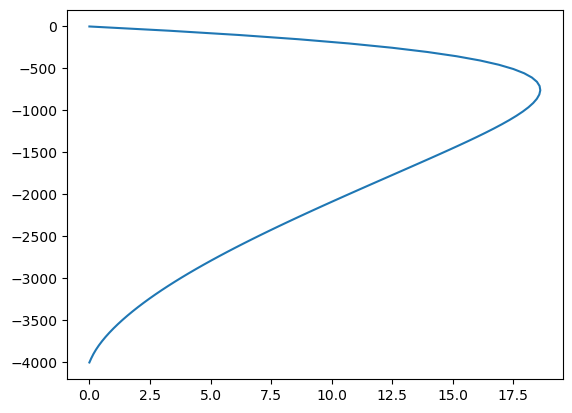

In [2]:
plt.plot(AMOC.Psi, z)

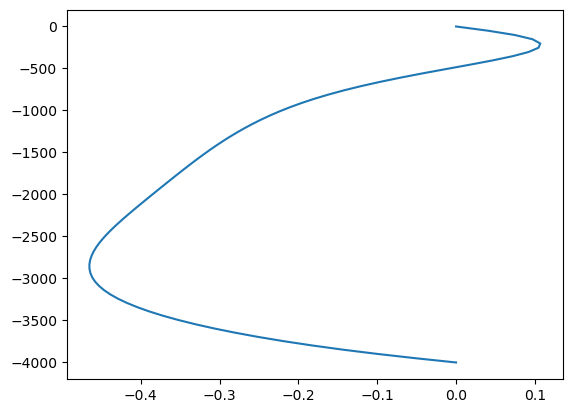

In [3]:
plt.plot(PMOC.Psi, z)

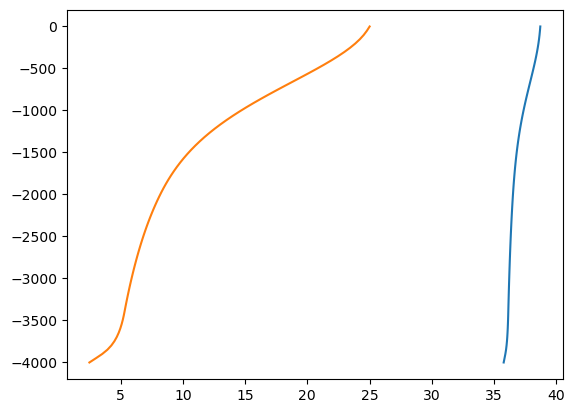

In [13]:
plt.plot(Atl.S, z)
plt.plot(Atl.T, z)

In [3]:
bn

array([-0.01086948, -0.01062191, -0.01047368, -0.01035171, -0.01025936,
       -0.01018868, -0.01013332, -0.01008896, -0.01005267, -0.01002246,
       -0.00999692, -0.00997504, -0.00995584, -0.00993745, -0.0099186 ,
       -0.00989929, -0.00987949, -0.00985919, -0.00983838, -0.00981705,
       -0.00979516, -0.00977271, -0.00974967, -0.00972601, -0.0097017 ,
       -0.00967671, -0.00965099, -0.00962452, -0.00959723, -0.00956907,
       -0.00953998, -0.00950989, -0.00947873, -0.00944641, -0.00941284,
       -0.00937791, -0.00934148, -0.00930341, -0.00926351, -0.0092216 ,
       -0.00917732, -0.00913014, -0.00907952, -0.00902497, -0.00896589,
       -0.00890161, -0.00883131, -0.00875401, -0.00866853, -0.00857359,
       -0.00846798, -0.00835023, -0.00821863, -0.00807126, -0.00790595,
       -0.00772024, -0.00751138, -0.00727623, -0.00701128, -0.00671255,
       -0.00637557, -0.00599531, -0.00556628, -0.00508262, -0.00453823,
       -0.00392693, -0.00324279, -0.00248066, -0.00163679, -0.00

In [103]:
bs_SO_ = np.array([-1.10000000e-03, -9.21701902e-04, -7.43403804e-04, -5.65105706e-04,
       -3.86807608e-04, -2.08509510e-04, -3.02114125e-05,  1.48086685e-04,
        3.26384783e-04,  5.04682881e-04,  6.62907826e-04,  8.30871713e-04,
        1.01752667e-03,  1.22276906e-03,  1.44648497e-03,  1.68855019e-03,
        1.94883034e-03,  2.22718094e-03,  2.52344745e-03,  2.83746541e-03,
        3.16906050e-03,  3.51804864e-03,  3.88423608e-03,  4.26741954e-03,
        4.66738630e-03,  5.08391433e-03,  5.51677239e-03,  5.96572019e-03,
        6.43050849e-03,  6.91087928e-03,  7.40656588e-03,  7.91729312e-03,
        8.44277748e-03,  8.98272722e-03,  9.53684262e-03,  1.01048160e-02,
        1.06863322e-02,  1.12810683e-02,  1.18886941e-02,  1.25088724e-02,
        1.31412587e-02,  1.37855022e-02,  1.44412451e-02,  1.51081235e-02,
        1.57857670e-02,  1.64737995e-02,  1.71718391e-02,  1.78794982e-02,
        1.85963841e-02,  1.93220986e-02,  2.00562391e-02])
bs_SO = g * (alpha * (Ts_SO - T0) - beta * (Ss_SO - S0))  
diff = bs_SO - bs_SO_
print(diff)

[-0.01255876 -0.01280025 -0.01298758 -0.01312073 -0.01319986 -0.01322537
 -0.01319786 -0.01311815 -0.01298725 -0.01280639 -0.0125569  -0.01227021
 -0.01195707 -0.01161934 -0.01125905 -0.01087839 -0.01047967 -0.01006536
 -0.00963803 -0.00920037 -0.00875518 -0.00830534 -0.0078538  -0.00740359
 -0.00695779 -0.00651951 -0.00609189 -0.0056781  -0.00528128 -0.00490457
 -0.00455111 -0.00422395 -0.00392612 -0.00366059 -0.00343022 -0.00323782
 -0.00308605 -0.0029775  -0.00291462 -0.0028997  -0.00293491 -0.00302226
 -0.00316358 -0.00336055 -0.00361465 -0.00392717 -0.00429921 -0.00473167
 -0.00522525 -0.00578043 -0.00639748]


In [111]:
Ts_SO

array([-1.96165327e+00, -1.99385981e+00, -1.99846478e+00, -1.97545001e+00,
       -1.92490633e+00, -1.84703321e+00, -1.74213797e+00, -1.61063459e+00,
       -1.45304206e+00, -1.26998232e+00, -1.06217783e+00, -8.30448685e-01,
       -5.75709426e-01, -2.98965390e-01, -1.30875743e-03,  3.16085755e-01,
        6.51965538e-01,  1.00500503e+00,  1.37381093e+00,  1.75692775e+00,
        2.15284350e+00,  2.55999567e+00,  2.97677742e+00,  3.40154391e+00,
        3.83261877e+00,  4.26830076e+00,  4.70687042e+00,  5.14659694e+00,
        5.58574490e+00,  6.02258120e+00,  6.45538184e+00,  6.88243874e+00,
        7.30206653e+00,  7.71260911e+00,  8.11244625e+00,  8.50000000e+00,
        8.87374084e+00,  9.23219380e+00,  9.57394423e+00,  9.89764338e+00,
        1.02020138e+01,  1.04858542e+01,  1.07480445e+01,  1.09875498e+01,
        1.12034251e+01,  1.13948182e+01,  1.15609739e+01,  1.17012365e+01,
        1.18150523e+01,  1.19019723e+01,  1.19616533e+01])

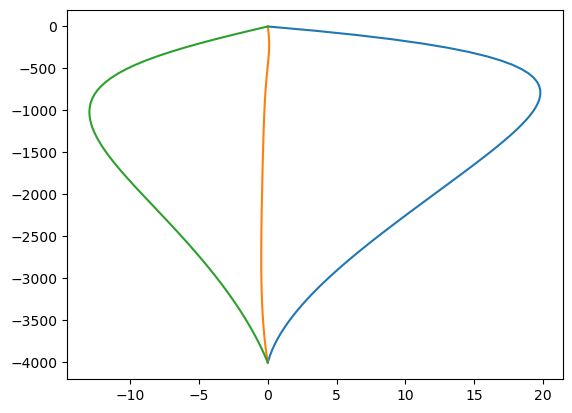

In [96]:
plt.plot(AMOC.Psi, z)
plt.plot(PMOC.Psi, z)
plt.plot(ZOC.Psi, z)

In [106]:
z[0]

np.float64(-4000.0)